In [9]:
import numpy as np

x = np.array([
    1.68,-0.15,-0.76,-1.31,-1.23,
    0.83,0.51,-0.26,-0.50,-0.62,
    1.20,2.19,1.77,1.40,2.61,
    -0.19,1.88,2.45,1.55,1.29
])

C = np.r_[0, np.cumsum(x)]

first_signal = None

for n in range(1, 21):
    for i in range(0, n):
        Li = C[n] - 3.502 - 0.5*(n-i)
        if C[i] < Li:
            first_signal = {
                "n": n,
                "i": i,
                "C_i": C[i],
                "L_i": Li,
                "C_n": C[n]
            }
            break
    
    if first_signal is not None:
        break

print("First signal:")
print(f"n = {first_signal['n']}")
print(f"i = {first_signal['i']}")
print(f"C_i = {first_signal['C_i']:.3f}")
print(f"L_i = {first_signal['L_i']:.3f}")
print(f"C_n = {first_signal['C_n']:.3f}")
print(f"C_i < L_i: {first_signal['C_i'] < first_signal['L_i']}")

First signal:
n = 13
i = 10
C_i = -1.810
L_i = -1.652
C_n = 3.350
C_i < L_i: True


In [14]:
import numpy as np
x = np.array([
1.68,-0.15,-0.76,-1.31,-1.23,
0.83,0.51,-0.26,-0.50,-0.62,
1.20,2.19,1.77,1.40,2.61,
-0.19,1.88,2.45,1.55,1.29
])
k = 0.5
h = 3.502
C_plus = 0
first_signal = None
for n, xn in enumerate(x, start=1):
    C_plus = max(0, C_plus + xn - k)
    print(f"n = {n:2d}, x_n = {xn:5.2f}, C_plus = {C_plus:6.3f}")
    if C_plus > h and first_signal is None:
        first_signal = {
        "n": n,
        "x_n": xn,
        "C_plus": C_plus
        }
        break
print("\nFirst signal:")
print(f"n = {first_signal['n']}")
print(f"C_plus = {first_signal['C_plus']:.3f}")
print(f"C_plus > h: {first_signal['C_plus'] > h}")

n =  1, x_n =  1.68, C_plus =  1.180
n =  2, x_n = -0.15, C_plus =  0.530
n =  3, x_n = -0.76, C_plus =  0.000
n =  4, x_n = -1.31, C_plus =  0.000
n =  5, x_n = -1.23, C_plus =  0.000
n =  6, x_n =  0.83, C_plus =  0.330
n =  7, x_n =  0.51, C_plus =  0.340
n =  8, x_n = -0.26, C_plus =  0.000
n =  9, x_n = -0.50, C_plus =  0.000
n = 10, x_n = -0.62, C_plus =  0.000
n = 11, x_n =  1.20, C_plus =  0.700
n = 12, x_n =  2.19, C_plus =  2.390
n = 13, x_n =  1.77, C_plus =  3.660

First signal:
n = 13
C_plus = 3.660
C_plus > h: True


In [18]:
import numpy as np

def estimate_arl0(k, h, M=10**5, seed=611211106):
    rng = np.random.default_rng(seed)
    RL = np.zeros(M, dtype=int)

    for m in range(M):
        C_plus = 0
        n = 0

        while True:
            n += 1
            x = rng.normal(0, 1)
            C_plus = max(0, C_plus + x - k)

            if C_plus > h:
                RL[m] = n
                break

    return RL.mean()

settings = [
    (0.25, 3.5),
    (0.25, 5.5),
    (0.5, 3.5)
]

for k, h in settings:
    arl0 = estimate_arl0(k, h)
    print(f"k = {k}, h = {h}, ARL0 = {arl0:.3f}")

k = 0.25, h = 3.5, ARL0 = 55.564
k = 0.25, h = 5.5, ARL0 = 189.249
k = 0.5, h = 3.5, ARL0 = 199.932


k = 0.25, h = 3.5, ARL0 = 55.564
k = 0.25, h = 5.5, ARL0 = 189.249
k = 0.5, h = 3.5, ARL0 = 199.932


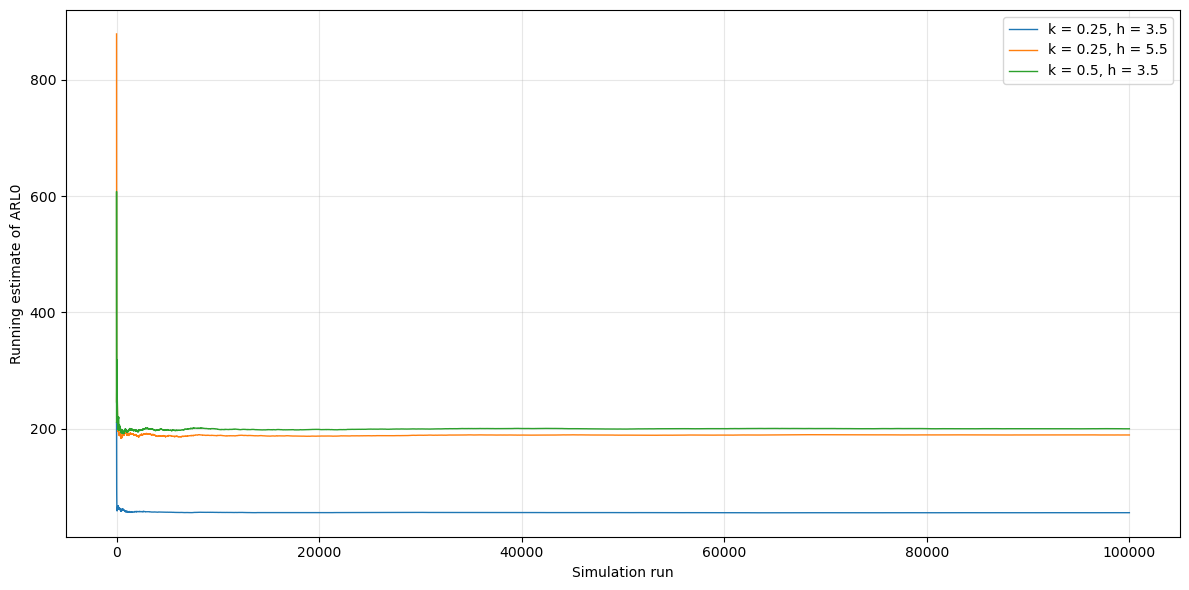

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_rl(k, h, M=10**5, seed=611211106):
    rng = np.random.default_rng(seed)
    RL = np.zeros(M, dtype=int)

    for m in range(M):
        C_plus = 0
        n = 0

        while True:
            n += 1
            x = rng.normal(0, 1)
            C_plus = max(0, C_plus + x - k)

            if C_plus > h:
                RL[m] = n
                break

    return RL

settings = [
    (0.25, 3.5),
    (0.25, 5.5),
    (0.5, 3.5)
]

M = 10**5

plt.figure(figsize=(12, 6))

for k, h in settings:
    RL = simulate_rl(k, h, M=M, seed=611211106)
    running_arl0 = np.cumsum(RL) / np.arange(1, M + 1)

    plt.plot(
        np.arange(1, M + 1),
        running_arl0,
        linewidth=1,
        label=f"k = {k}, h = {h}"
    )
    print(f"k = {k}, h = {h}, ARL0 = {RL.mean():.3f}")

plt.xlabel("Simulation run")
plt.ylabel("Running estimate of ARL0")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
import numpy as np

def estimate_arl0_fast(k, h, M=10000, seed=611211106):
    rng = np.random.default_rng(seed)

    C = np.zeros(M)
    RL = np.zeros(M, dtype=int)
    alive = np.ones(M, dtype=bool)

    n = 0
    while alive.any():
        n += 1
        x = rng.normal(0, 1, alive.sum())
        C[alive] = np.maximum(0, C[alive] + x - k)

        signal = alive & (C > h)
        RL[signal] = n
        alive[signal] = False

    return RL.mean()


def search_h_fast(target_arl0, k, h0, rho=0.5, M_search=5000, M_final=100000):
    h_low = h0 - 0.3
    h_high = h0 + 0.3

    while True:
        h_mid = (h_low + h_high) / 2
        arl_mid = estimate_arl0_fast(k, h_mid, M=M_search)

        if abs(arl_mid - target_arl0) <= rho:
            break

        if arl_mid < target_arl0:
            h_low = h_mid
        else:
            h_high = h_mid

    arl_final = estimate_arl0_fast(k, h_mid, M=M_final)
    return h_mid, arl_final

settings = [
    (350, 0.25, 6.6),
    (350, 0.50, 4.04),
    (550, 0.50, 4.48)
]

for target_arl0, k, h0 in settings:
    h, arl0 = search_h_fast(target_arl0, k, h0)
    print(f"Target ARL0 = {target_arl0}, k = {k}, h = {h:.3f}, ARL0 = {arl0:.3f}")

KeyboardInterrupt: 